In [1]:
# ==========================================
# Greenhouse 분석 + 전처리 방식 테스트 + Smartfarm 실제 CO2 검증 통합 코드
# ==========================================
# 전체 목적
# 1) Greenhouse 데이터의 eCO2를 이용해 센서 분포, 시간 패턴, 이상값 후보를 분석한다.
# 2) IQR / Modified Z-score / IQR+상관관계 기반 전처리 방식이 eCO2 예측 성능에 미치는 영향을 비교한다.
# 3) Greenhouse에서 얻은 결론을 바탕으로 Smartfarm 실제 내부 CO2 데이터에서 최종 검증을 수행한다.
#
# 주의
# - Greenhouse의 greenhouse_equivalent_co2_ppm은 실제 CO2가 아니라 eCO2 추정값이다.
# - 따라서 Greenhouse는 전처리 전략 검토용으로 사용한다.
# - Smartfarm 데이터의 내부CO2를 최종 실제 CO2 예측 대상으로 사용한다.
# ==========================================

import os
import zipfile
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------
# 파일 경로 설정
# ------------------------------------------
# Colab에서 사용하는 파일명에 맞게 수정하면 된다.
GREENHOUSE_DATA_PATH = "archive (4).zip"       # 예: "20210703_greenhouse_data.csv" 또는 "archive (4).zip"
SMARTFARM_DATA_PATH = "smartfarm_data.csv"     # 예: "smartfarm_data.csv" 또는 "2024_22_ds.zip"

# Smartfarm 실제 CO2 검증까지 실행할지 여부
RUN_SMARTFARM_VALIDATION = True

# Greenhouse 분석 변수
GH_MAIN_COLS = [
    "gh_temp_c",
    "gh_humidity_pct",
    "gh_lux",
    "gh_eco2_ppm"
]

# 결과 저장 폴더
OUTPUT_DIR = "project_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [2]:
# ==========================================
# 1. 공통 유틸 함수
# ==========================================

def find_existing_path(candidates):
    """후보 파일명 중 실제 존재하는 첫 번째 경로를 반환한다."""
    for path in candidates:
        if path and os.path.exists(path):
            return path
    return None


def read_csv_flexible(path_or_buffer, sep=None, decimal=None):
    """인코딩/구분자 차이를 고려해 CSV를 읽는다."""
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    last_error = None

    for enc in encodings:
        try:
            if sep is None:
                return pd.read_csv(path_or_buffer, encoding=enc, low_memory=False)
            return pd.read_csv(path_or_buffer, encoding=enc, sep=sep, decimal=decimal, low_memory=False)
        except Exception as e:
            last_error = e

    raise last_error


def load_csv_or_zip(path, csv_sep=None, csv_decimal=None):
    """CSV 또는 ZIP 안의 첫 번째 CSV 파일을 읽는다."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {path}")

    if path.lower().endswith(".zip"):
        with zipfile.ZipFile(path) as z:
            csv_names = [name for name in z.namelist() if name.lower().endswith(".csv")]
            if not csv_names:
                raise ValueError("ZIP 파일 안에 CSV 파일이 없습니다.")
            csv_name = csv_names[0]
            print(f"ZIP 내부 CSV 사용: {csv_name}")
            with z.open(csv_name) as f:
                return read_csv_flexible(f, sep=csv_sep, decimal=csv_decimal)
    else:
        return read_csv_flexible(path, sep=csv_sep, decimal=csv_decimal)


def regression_metrics(y_true, y_pred):
    """회귀 모델 평가 지표를 계산한다."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }


def show_basic_dataframe_info(df, name):
    """데이터프레임 기본 정보를 출력한다."""
    print(f"[{name} 기본 정보]")
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    display(df.head())


In [3]:
# ==========================================
# 2. Greenhouse 데이터 로드 및 기본 정리
# ==========================================

def load_greenhouse_data(path):
    """Greenhouse 데이터를 불러오고 분석용 컬럼명으로 정리한다."""
    # Kaggle greenhouse CSV는 보통 ; 구분자와 , 소수점을 사용한다.
    df = load_csv_or_zip(path, csv_sep=";", csv_decimal=",")

    rename_map = {
        "created": "timestamp",
        "greenhous_temperature_celsius": "gh_temp_c",
        "greenhouse_temperature_celsius": "gh_temp_c",
        "greenhouse_humidity_percentage": "gh_humidity_pct",
        "greenhouse_illuminance_lux": "gh_lux",
        "greenhouse_total_volatile_organic_compounds_ppb": "gh_tvoc_ppb",
        "greenhouse_equivalent_co2_ppm": "gh_eco2_ppm",
        "online_temperature_celsius": "online_temp_c",
        "online_humidity_percentage": "online_humidity_pct",
    }
    df = df.rename(columns=rename_map)

    required_cols = ["timestamp"] + GH_MAIN_COLS
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Greenhouse 필수 컬럼이 없습니다: {missing_cols}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()

    numeric_cols = [col for col in df.columns if col != "timestamp"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values("timestamp").reset_index(drop=True)
    return df

# 경로 자동 보정: Colab에서는 사용자가 파일명을 수정하면 된다.
greenhouse_candidates = [
    GREENHOUSE_DATA_PATH,
    "20210703_greenhouse_data.csv",
    "archive (4).zip",
]
selected_greenhouse_path = find_existing_path(greenhouse_candidates)
if selected_greenhouse_path is None:
    raise FileNotFoundError("Greenhouse 데이터 파일을 찾을 수 없습니다. GREENHOUSE_DATA_PATH를 확인하세요.")

gh_raw = load_greenhouse_data(selected_greenhouse_path)

show_basic_dataframe_info(gh_raw, "Greenhouse")
print("\n기간:", gh_raw["timestamp"].min(), "~", gh_raw["timestamp"].max())
print("\n주요 변수 결측치")
display(gh_raw[GH_MAIN_COLS].isna().sum().to_frame("missing_count"))


[Greenhouse 기본 정보]
shape: (17562, 9)
columns: ['id', 'gh_temp_c', 'gh_humidity_pct', 'gh_lux', 'online_temp_c', 'online_humidity_pct', 'gh_tvoc_ppb', 'gh_eco2_ppm', 'timestamp']


,id,gh_temp_c,gh_humidity_pct,gh_lux,online_temp_c,online_humidity_pct,gh_tvoc_ppb,gh_eco2_ppm,timestamp
0,361496,13.223257,68.055576,0.0,7.3,89.0,370.0,1080.444444,2021-03-03 20:10:04
1,361543,13.149615,68.271154,0.0,6.3,91.0,380.3,1068.100000,2021-03-03 20:20:03
2,361595,13.094339,68.402229,0.0,6.3,91.0,371.0,1022.700000,2021-03-03 20:30:04
3,361647,12.989395,68.483559,0.0,5.3,94.0,363.0,995.600000,2021-03-03 20:40:03
4,361699,12.901927,68.556920,0.0,5.4,94.0,350.0,960.888889,2021-03-03 20:50:05



기간: 2021-03-03 20:10:04 ~ 2021-07-03 20:00:11

주요 변수 결측치


,missing_count
gh_temp_c,398
gh_humidity_pct,398
gh_lux,398
gh_eco2_ppm,398


[Greenhouse timestamp 간격 요약]


,interval_sec
count,17561.000000
mean,600.205398
std,27.345634
min,490.000000
50%,600.000000
90%,603.000000
95%,604.000000
99%,606.000000
max,4205.000000


중앙 측정 간격: 600.0초
중앙값 ±10% 이내 비율: 99.98%
중앙값 2배 이상 긴 간격 개수: 1

[Greenhouse 주요 변수 기술통계량]


,count,mean,std,min,25%,50%,75%,max
gh_temp_c,17164.0,25.874693,13.038214,4.972237,14.951478,24.121462,31.744516,77.566312
gh_humidity_pct,17164.0,52.910666,13.079384,15.313954,45.488623,55.613870,63.771343,82.900305
gh_lux,17164.0,3722.243705,5738.124414,0.000000,0.000000,901.327778,5239.600000,36489.333333
gh_eco2_ppm,17164.0,1219.092382,1234.655687,400.000000,424.000000,985.950000,1385.925000,18113.400000



[Greenhouse 주요 변수 결측 패턴]


,missing_count,missing_ratio_%
gh_temp_c,398,2.266257
gh_humidity_pct,398,2.266257
gh_lux,398,2.266257
gh_eco2_ppm,398,2.266257



[Greenhouse 시간대별 평균]


,gh_temp_c,gh_humidity_pct,gh_lux,gh_eco2_ppm
hour,,,,
0,18.558784,60.791725,0.000000,750.504410
1,18.146061,61.393631,0.000000,733.536489
2,17.798954,61.830568,0.000000,717.170658
3,17.478379,62.246585,0.000000,723.279503
4,17.289838,62.537226,0.208638,731.510136
5,17.104795,62.778561,49.242111,739.497735
6,17.356794,62.792302,437.984572,750.968266
7,18.928465,61.805357,1673.907146,823.174686
8,22.462574,58.575381,4062.511130,1049.608017



[낮(True)/밤(False) 평균·표준편차]


gh_temp_c            gh_humidity_pct                  gh_lux  \
                 mean        std            mean        std         mean   
is_daytime                                                                 
False       19.084954   7.236235       59.972211   7.376806   218.624081   
True        32.661268  13.980147       45.852411  13.711897  7224.230701   

                         gh_eco2_ppm               
                    std         mean          std  
is_daytime                                         
False        540.148922   775.885545   382.952297  
True        6404.108715  1662.092691  1583.981257

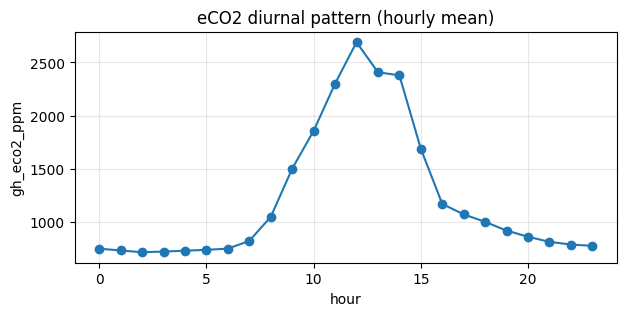


[Greenhouse Pearson 상관관계]


,gh_temp_c,gh_humidity_pct,gh_lux,gh_eco2_ppm
gh_temp_c,1.000000,-0.930195,0.57967,0.382968
gh_humidity_pct,-0.930195,1.000000,-0.58723,-0.368316
gh_lux,0.579670,-0.587230,1.00000,0.362720
gh_eco2_ppm,0.382968,-0.368316,0.36272,1.000000



[Greenhouse Spearman 상관관계]


,gh_temp_c,gh_humidity_pct,gh_lux,gh_eco2_ppm
gh_temp_c,1.000000,-0.910375,0.596710,0.049636
gh_humidity_pct,-0.910375,1.000000,-0.603986,-0.093568
gh_lux,0.596710,-0.603986,1.000000,0.339605
gh_eco2_ppm,0.049636,-0.093568,0.339605,1.000000


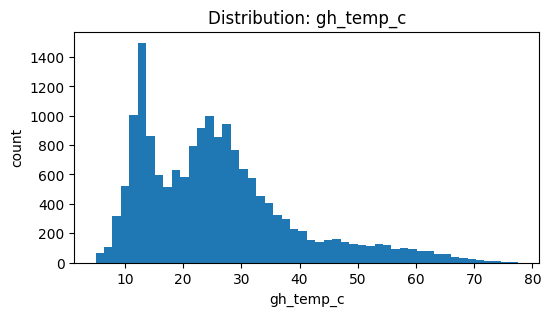

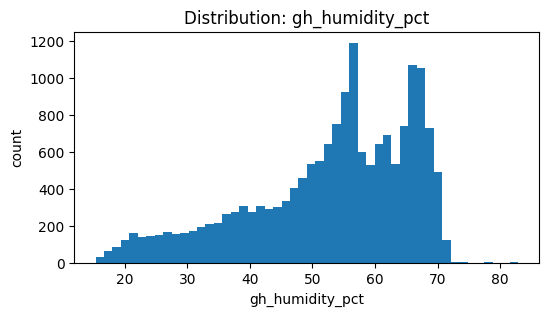

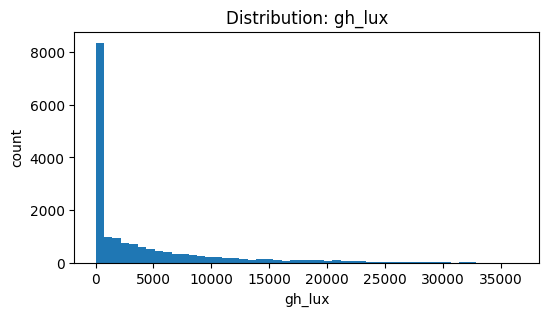

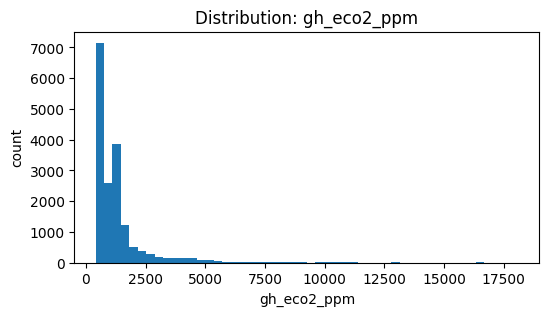

In [4]:
# ==========================================
# 3. Greenhouse 데이터 분석
# ==========================================
# 이 단계의 목적은 이상값 기준을 바로 정하는 것이 아니라,
# 센서값의 분포, 시간 간격, 결측 패턴, 시간대별 패턴, 센서 간 관계를 확인하는 것이다.

# ------------------------------------------
# 3-1. 측정 간격 분석
# ------------------------------------------
gh_analysis = gh_raw.copy().sort_values("timestamp")
gh_analysis["interval_sec"] = gh_analysis["timestamp"].diff().dt.total_seconds()

interval_summary = gh_analysis["interval_sec"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame("interval_sec")
print("[Greenhouse timestamp 간격 요약]")
display(interval_summary)

median_interval = gh_analysis["interval_sec"].median()
within_10pct = gh_analysis["interval_sec"].between(median_interval * 0.9, median_interval * 1.1).mean() * 100
long_gap_count = (gh_analysis["interval_sec"] >= median_interval * 2).sum()

print(f"중앙 측정 간격: {median_interval:.1f}초")
print(f"중앙값 ±10% 이내 비율: {within_10pct:.2f}%")
print(f"중앙값 2배 이상 긴 간격 개수: {long_gap_count}")

# ------------------------------------------
# 3-2. 기술통계량
# ------------------------------------------
print("\n[Greenhouse 주요 변수 기술통계량]")
descriptive_stats = gh_analysis[GH_MAIN_COLS].describe().T
display(descriptive_stats)

# ------------------------------------------
# 3-3. 결측 패턴
# ------------------------------------------
missing_summary = gh_analysis[GH_MAIN_COLS].isna().sum().to_frame("missing_count")
missing_summary["missing_ratio_%"] = missing_summary["missing_count"] / len(gh_analysis) * 100
print("\n[Greenhouse 주요 변수 결측 패턴]")
display(missing_summary)

# ------------------------------------------
# 3-4. 시간대별 평균 패턴
# ------------------------------------------
gh_analysis["hour"] = gh_analysis["timestamp"].dt.hour
hourly_mean = gh_analysis.groupby("hour")[GH_MAIN_COLS].mean()
print("\n[Greenhouse 시간대별 평균]")
display(hourly_mean)

# 낮/밤 비교: eCO2의 일주기(diurnal) 패턴을 먼저 확인한다.
# (도메인 사실) 밀폐 온실에서 CO2는 호흡 때문에 '밤에 높고' 광합성 때문에 '낮에 낮아진다'.
# 보통 새벽(6~9시) 부근에서 최고, 이른 오후에 최저를 보인다.
# 이 패턴을 먼저 파악해야, 야간 고농도 CO2를 '센서 오류'가 아니라 '정상 변동'으로 구분할 수 있다.
gh_analysis["is_daytime"] = (gh_analysis["hour"] >= 7) & (gh_analysis["hour"] <= 18)
daynight = gh_analysis.groupby("is_daytime")[GH_MAIN_COLS].agg(["mean", "std"])
print("\n[낮(True)/밤(False) 평균·표준편차]")
display(daynight)

plt.figure(figsize=(7, 3))
plt.plot(hourly_mean.index, hourly_mean["gh_eco2_ppm"], marker="o")
plt.title("eCO2 diurnal pattern (hourly mean)")
plt.xlabel("hour")
plt.ylabel("gh_eco2_ppm")
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------
# 3-5. 상관관계
# ------------------------------------------
pearson_corr = gh_analysis[GH_MAIN_COLS].corr(method="pearson")
spearman_corr = gh_analysis[GH_MAIN_COLS].corr(method="spearman")
print("\n[Greenhouse Pearson 상관관계]")
display(pearson_corr)
print("\n[Greenhouse Spearman 상관관계]")
display(spearman_corr)

# ------------------------------------------
# 3-6. 분포 시각화
# ------------------------------------------
for col in GH_MAIN_COLS:
    plt.figure(figsize=(6, 3))
    plt.hist(gh_analysis[col].dropna(), bins=50)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

# 분석 결과 저장
descriptive_stats.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_descriptive_stats.csv"), encoding="utf-8-sig")
missing_summary.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_missing_summary.csv"), encoding="utf-8-sig")
pearson_corr.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_pearson_corr.csv"), encoding="utf-8-sig")
spearman_corr.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_spearman_corr.csv"), encoding="utf-8-sig")
hourly_mean.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_hourly_mean.csv"), encoding="utf-8-sig")


In [5]:
# ==========================================
# 4. Greenhouse 이상값 후보 탐지 및 전처리 함수
# ==========================================
# 본 코드는 '분포 기반' 탐지만 수행한다 (시계열 기반 탐지는 팀원 담당).
#   - get_iqr_masks(IQR), modified_zscore_mask(MAD 기반): 값 분포에서 극단값 탐지
#   - make_context_masks: 센서 간 상관/robust z-score로 '오류 vs 정상 변동' 보조 판정

def interpolate_greenhouse_by_time(data, cols):
    """Greenhouse 센서 결측값을 timestamp 기준으로 선형 보간한다."""
    result = data.copy().sort_values("timestamp")
    result = result.set_index("timestamp")
    result[cols] = result[cols].interpolate(method="time")
    result[cols] = result[cols].ffill().bfill()
    result = result.reset_index()
    return result


def get_iqr_masks(data, cols, k=1.5, add_daytime_lux_zero=True):
    """IQR 기준으로 변수별 이상값 후보 mask와 상하한값을 계산한다."""
    temp = data.copy()
    temp["hour"] = temp["timestamp"].dt.hour

    masks = {}
    thresholds = {}

    for col in cols:
        q1 = temp[col].quantile(0.25)
        q3 = temp[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr

        thresholds[col] = {"Q1": q1, "Q3": q3, "IQR": iqr, "lower": lower, "upper": upper}
        masks[col] = (temp[col] < lower) | (temp[col] > upper)

    # 조도 0은 야간에는 정상일 수 있으므로, 낮 시간대 0 lux만 조건부 이상값 후보로 추가한다.
    if add_daytime_lux_zero and "gh_lux" in cols:
        daytime_lux_zero = (
            (temp["hour"] >= 7) &
            (temp["hour"] <= 18) &
            (temp["gh_lux"] == 0)
        )
        masks["gh_lux"] = masks["gh_lux"] | daytime_lux_zero

    return masks, thresholds


def modified_zscore_mask(series, threshold=3.5):
    """MAD 기반 Modified Z-score 이상값 후보 mask를 계산한다."""
    median = series.median()
    mad = np.median(np.abs(series.dropna() - median))
    if mad == 0 or np.isnan(mad):
        return pd.Series(False, index=series.index)
    modified_z = 0.6745 * (series - median) / mad
    return modified_z.abs() > threshold


def robust_zscore(series):
    """중앙값과 MAD 기반 robust z-score를 계산한다."""
    median = series.median()
    mad = np.median(np.abs(series.dropna() - median))
    if mad == 0 or np.isnan(mad):
        return pd.Series(0, index=series.index)
    return 0.6745 * (series - median) / mad


def make_context_masks(data, iqr_masks, thresholds, cols, corr_threshold=0.5, related_z_threshold=1.0):
    """
    IQR 이상값 후보 중에서 센서 간 관계로 설명되지 않는 값만 최종 처리 대상으로 선정한다.
    예: 온도만 튀고 조도/습도 변화가 동반되지 않으면 처리 대상으로 본다.
    """
    temp = data.copy()

    any_iqr = pd.Series(False, index=temp.index)
    for col in cols:
        any_iqr = any_iqr | iqr_masks[col]

    normal_rows = (~any_iqr) & (~temp[cols].isna().any(axis=1))
    corr_matrix = temp.loc[normal_rows, cols].corr()

    for col in cols:
        temp[f"{col}_rz"] = robust_zscore(temp[col])

    final_masks = {}

    for target_col in cols:
        final_mask = pd.Series(False, index=temp.index)
        lower = thresholds[target_col]["lower"]
        upper = thresholds[target_col]["upper"]

        related_cols = [
            c for c in cols
            if c != target_col and abs(corr_matrix.loc[target_col, c]) >= corr_threshold
        ]

        for idx in temp.index[iqr_masks[target_col]]:
            value = temp.loc[idx, target_col]
            if pd.isna(value):
                continue

            if value > upper:
                target_direction = 1
            elif value < lower:
                target_direction = -1
            else:
                continue

            explained = False
            for related_col in related_cols:
                corr_value = corr_matrix.loc[target_col, related_col]
                related_rz = temp.loc[idx, f"{related_col}_rz"]
                expected_direction = target_direction * np.sign(corr_value)

                if expected_direction > 0 and related_rz > related_z_threshold:
                    explained = True
                elif expected_direction < 0 and related_rz < -related_z_threshold:
                    explained = True

            if not explained:
                final_mask.loc[idx] = True

        final_masks[target_col] = final_mask

    return final_masks


def apply_masks_and_interpolate(data, masks, cols):
    """이상값 후보를 NaN으로 바꾼 뒤 시간 보간한다."""
    result = data.copy()
    for col in cols:
        result.loc[masks[col], col] = np.nan
    result = interpolate_greenhouse_by_time(result, cols)
    return result


In [6]:
# ==========================================
# 5. Greenhouse 전처리 방식별 데이터셋 생성
# ==========================================
# missing_only: 실제 결측값만 보간한다.
# iqr_k1.5: IQR 1.5 기준 이상값 후보를 보간한다.
# iqr_k3.0: IQR 3.0 기준으로 더 보수적으로 처리한다.
# modified_z: Modified Z-score 기준 이상값 후보를 보간한다.
# iqr_context_with_eco2: IQR 후보 중 센서 간 관계로 설명되지 않는 값만 보간한다.

base_data = interpolate_greenhouse_by_time(gh_raw, GH_MAIN_COLS)

gh_datasets = {}
gh_datasets["missing_only"] = base_data.copy()

# IQR 1.5
masks_iqr15, th_iqr15 = get_iqr_masks(base_data, GH_MAIN_COLS, k=1.5)
gh_datasets["iqr_k1.5"] = apply_masks_and_interpolate(base_data, masks_iqr15, GH_MAIN_COLS)

# IQR 3.0
masks_iqr30, th_iqr30 = get_iqr_masks(base_data, GH_MAIN_COLS, k=3.0)
gh_datasets["iqr_k3.0"] = apply_masks_and_interpolate(base_data, masks_iqr30, GH_MAIN_COLS)

# Modified Z-score
masks_mz = {col: modified_zscore_mask(base_data[col], threshold=3.5) for col in GH_MAIN_COLS}
gh_datasets["modified_z"] = apply_masks_and_interpolate(base_data, masks_mz, GH_MAIN_COLS)

# IQR + 센서 간 관계 기반 처리
masks_context = make_context_masks(
    base_data,
    masks_iqr15,
    th_iqr15,
    GH_MAIN_COLS,
    corr_threshold=0.5,
    related_z_threshold=1.0,
)
gh_datasets["iqr_context_with_eco2"] = apply_masks_and_interpolate(base_data, masks_context, GH_MAIN_COLS)

# 전처리 요약표
preprocess_summary = []
for name, data in gh_datasets.items():
    row = {
        "dataset": name,
        "n_rows": len(data),
        "missing_after": int(data[GH_MAIN_COLS].isna().sum().sum())
    }
    for col in GH_MAIN_COLS:
        row[f"{col}_min"] = data[col].min()
        row[f"{col}_max"] = data[col].max()
    preprocess_summary.append(row)

gh_preprocess_summary_df = pd.DataFrame(preprocess_summary)
print("[Greenhouse 전처리 방식별 데이터 요약]")
display(gh_preprocess_summary_df)

# IQR 기준표와 이상값 개수
th_iqr15_df = pd.DataFrame(th_iqr15).T
iqr_count_df = pd.DataFrame({
    "variable": GH_MAIN_COLS,
    "iqr_k1.5_count": [int(masks_iqr15[col].sum()) for col in GH_MAIN_COLS],
    "context_count": [int(masks_context[col].sum()) for col in GH_MAIN_COLS],
    "modified_z_count": [int(masks_mz[col].sum()) for col in GH_MAIN_COLS],
})
print("\n[IQR k=1.5 기준값]")
display(th_iqr15_df)
print("\n[이상값 후보 개수 비교]")
display(iqr_count_df)

gh_preprocess_summary_df.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_preprocess_summary.csv"), index=False, encoding="utf-8-sig")
th_iqr15_df.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_iqr_thresholds.csv"), encoding="utf-8-sig")
iqr_count_df.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_outlier_counts.csv"), index=False, encoding="utf-8-sig")


[Greenhouse 전처리 방식별 데이터 요약]


,dataset,n_rows,missing_after,gh_temp_c_min,gh_temp_c_max,gh_humidity_pct_min,gh_humidity_pct_max,gh_lux_min,gh_lux_max,gh_eco2_ppm_min,gh_eco2_ppm_max
0,missing_only,17562,0,4.972237,77.566312,15.313954,82.900305,0.0,36489.333333,400.0,18113.400000
1,iqr_k1.5,17562,0,4.972237,56.727779,18.560566,82.900305,0.0,13068.800000,400.0,2828.903840
2,iqr_k3.0,17562,0,4.972237,77.566312,15.313954,82.900305,0.0,20945.300000,400.0,4262.444444
3,modified_z,17562,0,4.972237,67.746623,15.313954,82.900305,0.0,5938.888889,400.0,3481.100000
4,iqr_context_with_eco2,17562,0,4.972237,77.566312,15.313954,82.900305,0.0,36489.333333,400.0,2828.903840



[IQR k=1.5 기준값]


,Q1,Q3,IQR,lower,upper
gh_temp_c,14.759289,31.555390,16.796102,-10.434864,56.749543
gh_humidity_pct,45.771954,63.913558,18.141604,18.559548,91.125963
gh_lux,0.000000,5239.050000,5239.050000,-7858.575000,13097.625000
gh_eco2_ppm,431.500000,1390.794444,959.294444,-1007.441667,2829.736111



[이상값 후보 개수 비교]


,variable,iqr_k1.5_count,context_count,modified_z_count
0,gh_temp_c,636,0,95
1,gh_humidity_pct,125,0,0
2,gh_lux,1916,209,3962
3,gh_eco2_ppm,1249,1249,903


[분포 기반 탐지기별 이상값 후보 수]


,method,count
0,IQR_k1.5,1249
1,IQR_k3.0,572
2,Modified_Z(3.5),903



[몇 개 방법이 동시에 이상으로 판정했는가] (값이 클수록 강건한 이상값)


,n_methods_flagging,count
0,0,16313
1,1,346
2,2,331
3,3,572



[분류 결과]


,outlier_class,count,기준
0,sensor_error,1249,분포상 극단 + 센서 관계로 설명 안 됨
1,real_variation,0,분포상 극단 + 다른 센서도 일관 변동
2,normal,16313,정상 범위



[센서 오류 의심 예시 (상위 10개)]


,timestamp,gh_eco2_ppm
232,2021-03-05 10:50:04,2975.333333
233,2021-03-05 11:00:04,3239.444444
234,2021-03-05 11:10:05,3471.500000
235,2021-03-05 11:20:04,3528.400000
236,2021-03-05 11:30:05,3453.111111
237,2021-03-05 11:40:05,3220.500000
238,2021-03-05 11:50:06,3137.600000
239,2021-03-05 12:00:07,3333.444444
240,2021-03-05 12:10:03,3673.100000
241,2021-03-05 12:20:04,3904.200000


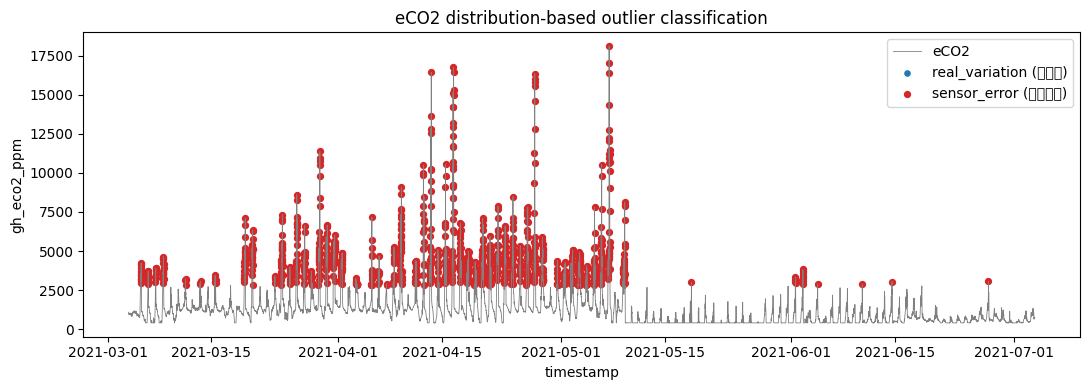

In [7]:
# ==========================================
# 5-B. 분포 기반 이상값 탐지 · 분류 분석  [담당: 본인 / 프로젝트 핵심]
# ==========================================
# 본 코드는 '분포 기반' 탐지만 수행한다 (시계열 기반 탐지는 팀원 담당).
# 분포 기반 탐지기:
#   - IQR (k=1.5, k=3.0) : 사분위 범위 밖의 값
#   - Modified Z-score   : 중앙값/MAD 기반, 평균-표준편차보다 이상값에 강건
# 핵심 질문: 분포상 극단값이 '센서 오류'인가 '정상 변동'인가?
#   -> 시간 정보 대신, 센서 간 관계(make_context_masks)로 구분한다.
#      다른 센서가 함께 일관되게 움직였으면 정상 변동, 아니면 센서 오류 의심.

TARGET_VAR = "gh_eco2_ppm"
s = base_data[TARGET_VAR].reset_index(drop=True)
ts = base_data["timestamp"].reset_index(drop=True)

# ------------------------------------------
# (1) 분포 기반 탐지기별 후보
# ------------------------------------------
m_iqr15 = masks_iqr15[TARGET_VAR].reset_index(drop=True).fillna(False).astype(bool)
m_iqr30 = masks_iqr30[TARGET_VAR].reset_index(drop=True).fillna(False).astype(bool)
m_mz    = modified_zscore_mask(s, threshold=3.5).reset_index(drop=True).fillna(False).astype(bool)

method_counts = pd.DataFrame({
    "method": ["IQR_k1.5", "IQR_k3.0", "Modified_Z(3.5)"],
    "count": [int(m_iqr15.sum()), int(m_iqr30.sum()), int(m_mz.sum())],
})
print("[분포 기반 탐지기별 이상값 후보 수]")
display(method_counts)

# ------------------------------------------
# (2) 탐지기 간 일치도: 여러 방법이 공통으로 잡을수록 '강건한 이상값'
# ------------------------------------------
agree_count = m_iqr15.astype(int) + m_iqr30.astype(int) + m_mz.astype(int)
agreement = pd.DataFrame({
    "n_methods_flagging": [0, 1, 2, 3],
    "count": [int((agree_count == k).sum()) for k in [0, 1, 2, 3]],
})
print("\n[몇 개 방법이 동시에 이상으로 판정했는가] (값이 클수록 강건한 이상값)")
display(agreement)

# ------------------------------------------
# (3) 센서 관계로 '설명되는가'로 분류 (시간 정보 미사용 -> 분포/관계 기반)
#   설명됨   -> real_variation (다른 센서도 일관되게 변동)
#   설명안됨 -> sensor_error 의심
# ------------------------------------------
candidate   = m_iqr15 | m_mz   # 분포 기반 후보(union)
unexplained = masks_context[TARGET_VAR].reset_index(drop=True).fillna(False).astype(bool)
sensor_error   = candidate & unexplained
real_variation = candidate & ~unexplained

outlier_class = pd.Series("normal", index=s.index)
outlier_class[real_variation] = "real_variation"
outlier_class[sensor_error]   = "sensor_error"

class_summary = pd.DataFrame({
    "outlier_class": ["sensor_error", "real_variation", "normal"],
    "count": [int(sensor_error.sum()), int(real_variation.sum()),
              int((outlier_class == "normal").sum())],
    "기준": [
        "분포상 극단 + 센서 관계로 설명 안 됨",
        "분포상 극단 + 다른 센서도 일관 변동",
        "정상 범위",
    ],
})
print("\n[분류 결과]")
display(class_summary)

# 센서 오류 의심 예시
err_idx = s.index[sensor_error]
print("\n[센서 오류 의심 예시 (상위 10개)]")
display(pd.DataFrame({"timestamp": ts[err_idx], TARGET_VAR: s[err_idx]}).head(10))

# ------------------------------------------
# 시각화: eCO2 위에 분류 결과 표시
# ------------------------------------------
plt.figure(figsize=(11, 4))
plt.plot(ts, s, linewidth=0.6, color="gray", label="eCO2")
plt.scatter(ts[real_variation], s[real_variation], s=14, color="tab:blue", label="real_variation (설명됨)")
plt.scatter(ts[sensor_error],   s[sensor_error],   s=18, color="tab:red",  label="sensor_error (설명불가)")
plt.title("eCO2 distribution-based outlier classification")
plt.xlabel("timestamp"); plt.ylabel(TARGET_VAR); plt.legend()
plt.tight_layout(); plt.show()

# ------------------------------------------
# 저장
# ------------------------------------------
labeled = pd.DataFrame({
    "timestamp": ts, TARGET_VAR: s,
    "iqr15_flag": m_iqr15.astype(int),
    "modified_z_flag": m_mz.astype(int),
    "unexplained": unexplained.astype(int),
    "outlier_class": outlier_class,
})
method_counts.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_detection_method_counts.csv"), index=False, encoding="utf-8-sig")
agreement.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_detection_agreement.csv"), index=False, encoding="utf-8-sig")
labeled.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_outlier_labeled.csv"), index=False, encoding="utf-8-sig")


In [8]:
# ==========================================
# 6. Greenhouse 전처리 방식별 모델링
# ==========================================
# 목표: 현재 시점 온도/습도/조도/eCO2를 이용해 다음 시점 eCO2를 예측한다.
# 이 단계는 최종 실제 CO2 모델이 아니라, 전처리 전략을 검토하기 위한 사전 실험이다.

def add_greenhouse_features(data):
    """Greenhouse 모델용 feature engineering."""
    result = data.copy().sort_values("timestamp")

    result["hour"] = result["timestamp"].dt.hour
    result["month"] = result["timestamp"].dt.month
    result["dayofweek"] = result["timestamp"].dt.dayofweek

    result["hour_sin"] = np.sin(2 * np.pi * result["hour"] / 24)
    result["hour_cos"] = np.cos(2 * np.pi * result["hour"] / 24)
    result["is_daytime"] = ((result["hour"] >= 7) & (result["hour"] <= 18)).astype(int)

    result["log_lux"] = np.log1p(result["gh_lux"].clip(lower=0))
    result["log_eco2"] = np.log1p(result["gh_eco2_ppm"].clip(lower=0))

    result["daytime_lux_zero_flag"] = ((result["is_daytime"] == 1) & (result["gh_lux"] == 0)).astype(int)
    result["eco2_floor_400_flag"] = (result["gh_eco2_ppm"] == 400).astype(int)

    return result


def make_greenhouse_model_data(data, target_series, feature_mode="with_current_eco2"):
    """Greenhouse 모델 입력 X와 예측 대상 y를 생성한다."""
    result = add_greenhouse_features(data)

    if feature_mode == "with_current_eco2":
        feature_cols = [
            "gh_temp_c",
            "gh_humidity_pct",
            "gh_lux",
            "gh_eco2_ppm",
            "hour_sin",
            "hour_cos",
            "is_daytime",
            "log_lux",
            "log_eco2",
            "daytime_lux_zero_flag",
            "eco2_floor_400_flag",
        ]
    elif feature_mode == "no_current_eco2":
        feature_cols = [
            "gh_temp_c",
            "gh_humidity_pct",
            "gh_lux",
            "hour_sin",
            "hour_cos",
            "is_daytime",
            "log_lux",
            "daytime_lux_zero_flag",
        ]
    else:
        raise ValueError("feature_mode는 with_current_eco2 또는 no_current_eco2만 가능")

    # 중요: target은 전처리 방식과 무관하게 "고정된 공통 정답"을 사용한다(아래 canonical_target_next 참고).
    result["target_eco2_next"] = target_series.reindex(result.index)
    model_data = result[feature_cols + ["target_eco2_next"]].dropna().copy()
    return model_data, feature_cols


def evaluate_greenhouse_models(data, dataset_name, target_series, feature_mode="with_current_eco2"):
    """전처리 데이터셋별 Greenhouse eCO2 예측 성능을 평가한다."""
    model_data, feature_cols = make_greenhouse_model_data(data, target_series, feature_mode=feature_mode)

    X = model_data[feature_cols]
    y = model_data["target_eco2_next"]

    split_idx = int(len(model_data) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    results = []

    # 기준 모델: 현재 eCO2를 다음 eCO2 예측값으로 그대로 사용
    if "gh_eco2_ppm" in feature_cols:
        y_pred = X_test["gh_eco2_ppm"].values
        row = {
            "dataset": dataset_name,
            "model": "Persistence_current_eco2",
            "feature_mode": feature_mode,
            "n_samples": len(model_data),
        }
        row.update(regression_metrics(y_test, y_pred))
        results.append(row)

    models = {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
        "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.03, max_leaf_nodes=31, l2_regularization=0.1, random_state=42),
    }

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        row = {
            "dataset": dataset_name,
            "model": model_name,
            "feature_mode": feature_mode,
            "n_samples": len(model_data),
        }
        row.update(regression_metrics(y_test, y_pred))
        results.append(row)

    return pd.DataFrame(results)

# ------------------------------------------
# 공통(canonical) 예측 대상 고정 — 통계적 혼동 방지
# ------------------------------------------
# 만약 전처리(이상값 보간)로 eCO2 자체를 평활한 뒤 그 값을 target으로 쓰면,
# 더 많이 평활한 데이터셋일수록 target 분산이 작아져 RMSE가 '자동으로' 낮아진다.
# 즉 "전처리 효과"가 아니라 "정답을 더 쉽게 만든 효과"를 측정하게 되는 교란이 생긴다.
# 이를 피하기 위해, 모든 전처리 방식에 대해 동일한 정답(missing_only 기준 다음 시점 eCO2)을
# 사용하고, 입력 feature만 전처리 방식별로 다르게 둔다.
canonical_target_next = base_data["gh_eco2_ppm"].shift(-1)
print("[공통 target 정보] target std =", round(float(canonical_target_next.std()), 3),
      "| 모든 전처리 방식이 동일한 정답으로 비교됨")

# 실행
all_gh_results = []
for dataset_name, data in gh_datasets.items():
    all_gh_results.append(
        evaluate_greenhouse_models(data, dataset_name, canonical_target_next, feature_mode="with_current_eco2")
    )

gh_result_df = pd.concat(all_gh_results, ignore_index=True)
gh_result_sorted = gh_result_df.sort_values(by="RMSE").reset_index(drop=True)

print("[Greenhouse 전처리 방식별 eCO2 예측 성능]")
display(gh_result_sorted)

gh_result_sorted.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_modeling_result.csv"), index=False, encoding="utf-8-sig")


[공통 target 정보] target std = 1226.207 | 모든 전처리 방식이 동일한 정답으로 비교됨
[Greenhouse 전처리 방식별 eCO2 예측 성능]


,dataset,model,feature_mode,n_samples,MAE,RMSE,R2
0,missing_only,HistGradientBoosting,with_current_eco2,17561,41.686775,77.438749,0.952955
1,missing_only,ExtraTrees,with_current_eco2,17561,36.231911,77.755011,0.952570
2,iqr_k1.5,Persistence_current_eco2,with_current_eco2,17561,34.740943,78.952802,0.951097
3,iqr_context_with_eco2,Persistence_current_eco2,with_current_eco2,17561,34.740943,78.952802,0.951097
4,modified_z,Persistence_current_eco2,with_current_eco2,17561,35.038164,80.254223,0.949472
5,iqr_k3.0,Persistence_current_eco2,with_current_eco2,17561,35.038164,80.254223,0.949472
6,missing_only,Persistence_current_eco2,with_current_eco2,17561,35.038164,80.254223,0.949472
7,missing_only,RandomForest,with_current_eco2,17561,37.723067,80.644027,0.948980
8,iqr_k3.0,ExtraTrees,with_current_eco2,17561,38.298210,87.906552,0.939376
9,missing_only,Ridge,with_current_eco2,17561,73.566707,104.290060,0.914673


In [9]:
# ==========================================
# 7. Smartfarm 실제 내부 CO2 데이터 로드 및 분석
# ==========================================
# 이 단계는 Greenhouse에서 도출한 방향을 실제 내부 CO2 데이터에 적용해 검증하는 단계다.
# Smartfarm 데이터가 없으면 SMARTFARM_DATA_PATH를 Colab 업로드 파일명에 맞게 수정한다.

if RUN_SMARTFARM_VALIDATION:
    smartfarm_candidates = [
        SMARTFARM_DATA_PATH,
        "smartfarm_data.csv",
        "2024_22_ds.zip",
    ]
    selected_smartfarm_path = find_existing_path(smartfarm_candidates)

    if selected_smartfarm_path is None:
        print("[주의] Smartfarm 데이터 파일을 찾지 못했습니다.")
        print("SMARTFARM_DATA_PATH를 실제 파일명으로 수정한 뒤 아래 셀부터 다시 실행하세요.")
        RUN_SMARTFARM_VALIDATION = False
    else:
        sf_raw = load_csv_or_zip(selected_smartfarm_path)
        show_basic_dataframe_info(sf_raw, "Smartfarm raw")

if RUN_SMARTFARM_VALIDATION:
    # 필수 컬럼 확인
    required_cols = ["농가id", "수집일자", "장비명", "측정값"]
    missing_cols = [col for col in required_cols if col not in sf_raw.columns]
    if missing_cols:
        raise ValueError(f"Smartfarm 필수 컬럼이 없습니다: {missing_cols}")

    sf_raw["수집일자"] = pd.to_datetime(sf_raw["수집일자"], errors="coerce")
    sf_raw["측정값"] = pd.to_numeric(sf_raw["측정값"], errors="coerce")
    sf_raw = sf_raw.dropna(subset=["농가id", "수집일자", "장비명", "측정값"]).copy()
    sf_raw = sf_raw.sort_values(["농가id", "수집일자"]).copy()

    print("[Smartfarm 장비명 빈도]")
    display(sf_raw["장비명"].value_counts().head(30))

    # 최종 검증에 사용할 장비명
    target_devices = [
        "내부CO2",
        "내부온도",
        "내부습도",
        "내부일사량",
        "외부온도",
        "외부습도",
    ]

    sf_selected = sf_raw[sf_raw["장비명"].isin(target_devices)].copy()
    print("\n[선택된 장비명 빈도]")
    display(sf_selected["장비명"].value_counts())

    # Long format → Wide format
    sf_wide = sf_selected.pivot_table(
        index=["농가id", "수집일자"],
        columns="장비명",
        values="측정값",
        aggfunc="mean"
    ).reset_index()
    sf_wide.columns.name = None

    sf_wide = sf_wide.rename(columns={
        "농가id": "farm_id",
        "수집일자": "timestamp",
        "내부CO2": "internal_co2_ppm",
        "내부온도": "internal_temp_c",
        "내부습도": "internal_humidity_pct",
        "내부일사량": "internal_light",
        "외부온도": "external_temp_c",
        "외부습도": "external_humidity_pct",
    })

    sf_wide = sf_wide.sort_values(["farm_id", "timestamp"]).copy()

    print("\n[Smartfarm wide 데이터]")
    print("shape:", sf_wide.shape)
    display(sf_wide.head())

    sf_sensor_cols = [
        "internal_co2_ppm",
        "internal_temp_c",
        "internal_humidity_pct",
        "internal_light",
        "external_temp_c",
        "external_humidity_pct",
    ]
    sf_sensor_cols = [col for col in sf_sensor_cols if col in sf_wide.columns]

    print("\n[Smartfarm 결측 요약]")
    sf_missing = sf_wide[sf_sensor_cols].isna().sum().to_frame("missing_count")
    sf_missing["missing_ratio_%"] = sf_missing["missing_count"] / len(sf_wide) * 100
    display(sf_missing)

    print("\n[Smartfarm 기술통계량]")
    sf_descriptive = sf_wide[sf_sensor_cols].describe().T
    display(sf_descriptive)

    print("\n[Smartfarm 상관관계]")
    sf_corr = sf_wide[sf_sensor_cols].corr()
    display(sf_corr)

    sf_missing.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_missing_summary.csv"), encoding="utf-8-sig")
    sf_descriptive.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_descriptive_stats.csv"), encoding="utf-8-sig")
    sf_corr.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_corr.csv"), encoding="utf-8-sig")


[Smartfarm raw 기본 정보]
shape: (2011441, 11)
columns: ['수집일자', '농가id', '작기번호', '품목명', '단체표준 분류명', '단체표준 항목명', '단체표준 항목2명', '장비명', '단위', '측정값', '보간데이터여부']


,수집일자,농가id,작기번호,품목명,단체표준 분류명,단체표준 항목명,단체표준 항목2명,장비명,단위,측정값,보간데이터여부
0,2024-10-15 00:00:00,PF_0010056_01,8075.0,80300,topvent,openingrate,leftsingle,좌측일중천창 개도,%,0.0,original
1,2024-10-15 00:00:00,PF_0010056_01,8075.0,80300,topvent,openingrate,rightsingle,우측일중천창 개도,%,0.0,original
2,2024-10-15 00:00:00,PF_0010056_01,8075.0,80300,topvent,openingrate,leftdouble,좌측이중천창 개도,%,0.0,original
3,2024-10-15 00:00:00,PF_0010056_01,8075.0,80300,topvent,openingrate,rightdouble,우측이중천창 개도,%,0.0,original
4,2024-10-15 00:00:00,PF_0010056_01,8075.0,80300,sidevent,openingrate,leftsingle,좌측일중측창 개도,%,0.0,original


[Smartfarm 장비명 빈도]


장비명
내부습도            232350
내부온도            232350
내부CO2           230261
지습              225894
이슬점온도           224704
토양EC            219689
지중온도            121096
근권부 온도          101630
내부일사량            29881
외부일사량            21816
외부온도             21816
외부풍속             21744
외부풍향             21503
CO2발생장치작동상태      21186
보광등작동상태          19996
훈증기작동상태          19996
누적일사량(가공-내부)     19800
강우감지             19632
3WAY벨브공급수온도      18629
누적일사량(가공_외부)     16344
절대습도             16344
(양액)배액PH         14216
(양액)배액EC         14216
유동팬작동상태          11924
좌측일중측창 개도        10673
우측일중측창 개도        10526
좌측일중천창 개도        10526
우측일중천창 개도        10526
좌측이중천창 개도        10331
우측이중천창 개도        10115
Name: count, dtype: int64


[선택된 장비명 빈도]


...

,missing_count,missing_ratio_%
internal_co2_ppm,2123,0.913574
internal_temp_c,34,0.014631
internal_humidity_pct,34,0.014631
internal_light,202503,87.141542
external_temp_c,210568,90.612090



[Smartfarm 기술통계량]


,count,mean,std,min,25%,50%,75%,max
internal_co2_ppm,230261.0,747.449851,367.233843,200.0,480.0,622.0,952.0,2631.00
internal_temp_c,232350.0,17.036565,6.592924,2.0,12.0,15.0,21.0,50.00
internal_humidity_pct,232350.0,79.874451,23.001583,0.0,72.0,90.0,96.0,100.00
internal_light,29881.0,40.964877,104.747484,0.0,0.0,0.0,21.0,918.00
external_temp_c,21816.0,11.887759,9.697027,-14.0,4.0,12.0,18.5,36.33



[Smartfarm 상관관계]


,internal_co2_ppm,internal_temp_c,internal_humidity_pct,internal_light,external_temp_c
internal_co2_ppm,1.000000,-0.442836,0.196582,-0.103213,-0.431326
internal_temp_c,-0.442836,1.000000,-0.451165,0.181135,0.804884
internal_humidity_pct,0.196582,-0.451165,1.000000,-0.287824,0.060529
internal_light,-0.103213,0.181135,-0.287824,1.000000,0.095286
external_temp_c,-0.431326,0.804884,0.060529,0.095286,1.000000


In [10]:
# ==========================================
# 8. Smartfarm 전처리 및 Feature Engineering
# ==========================================
# Greenhouse 실험 결과를 반영하여, Smartfarm에서는 이상값을 과도하게 제거하지 않는다.
# 물리적으로 불가능한 값만 NaN 처리하고, IQR 이상값 여부는 flag로 남긴다.
# 시간, lag, diff, rolling feature를 추가해 실제 내부 CO2 예측 성능을 검증한다.

if RUN_SMARTFARM_VALIDATION:
    sf_clean = sf_wide.copy()

    # ------------------------------------------
    # 8-1. 물리적으로 불가능한 값만 NaN 처리
    # ------------------------------------------
    if "internal_co2_ppm" in sf_clean.columns:
        sf_clean.loc[sf_clean["internal_co2_ppm"] < 0, "internal_co2_ppm"] = np.nan

    for col in ["internal_humidity_pct", "external_humidity_pct"]:
        if col in sf_clean.columns:
            sf_clean.loc[(sf_clean[col] < 0) | (sf_clean[col] > 100), col] = np.nan

    if "internal_light" in sf_clean.columns:
        sf_clean.loc[sf_clean["internal_light"] < 0, "internal_light"] = np.nan

    for col in ["internal_temp_c", "external_temp_c"]:
        if col in sf_clean.columns:
            sf_clean.loc[(sf_clean[col] < -30) | (sf_clean[col] > 80), col] = np.nan

    # ------------------------------------------
    # 8-2. 농가별 시간 기준 보간
    # ------------------------------------------
    def interpolate_smartfarm_by_farm(group):
        group = group.sort_values("timestamp").copy()
        group = group.set_index("timestamp")
        group[sf_sensor_cols] = group[sf_sensor_cols].interpolate(method="time")
        group[sf_sensor_cols] = group[sf_sensor_cols].ffill().bfill()
        group = group.reset_index()
        return group

    sf_preprocessed = (
        sf_clean
        .groupby("farm_id", group_keys=False)
        .apply(interpolate_smartfarm_by_farm)
        .sort_values(["farm_id", "timestamp"])
        .copy()
    )

    # ------------------------------------------
    # 8-3. 시간 변수 생성
    # ------------------------------------------
    sf_feat = sf_preprocessed.copy()
    sf_feat["hour"] = sf_feat["timestamp"].dt.hour
    sf_feat["dayofyear"] = sf_feat["timestamp"].dt.dayofyear
    sf_feat["month"] = sf_feat["timestamp"].dt.month
    sf_feat["dayofweek"] = sf_feat["timestamp"].dt.dayofweek

    sf_feat["hour_sin"] = np.sin(2 * np.pi * sf_feat["hour"] / 24)
    sf_feat["hour_cos"] = np.cos(2 * np.pi * sf_feat["hour"] / 24)
    sf_feat["doy_sin"] = np.sin(2 * np.pi * sf_feat["dayofyear"] / 365)
    sf_feat["doy_cos"] = np.cos(2 * np.pi * sf_feat["dayofyear"] / 365)
    sf_feat["is_daytime"] = ((sf_feat["hour"] >= 7) & (sf_feat["hour"] <= 18)).astype(int)

    # ------------------------------------------
    # 8-4. 분포 기반 log 변환 및 특수 상태 flag
    # ------------------------------------------
    if "internal_light" in sf_feat.columns:
        sf_feat["log_internal_light"] = np.log1p(sf_feat["internal_light"].clip(lower=0))
        sf_feat["daytime_light_zero_flag"] = (
            (sf_feat["is_daytime"] == 1) & (sf_feat["internal_light"] == 0)
        ).astype(int)

    if "internal_co2_ppm" in sf_feat.columns:
        sf_feat["log_internal_co2"] = np.log1p(sf_feat["internal_co2_ppm"].clip(lower=0))
        sf_feat["co2_floor_400_flag"] = (sf_feat["internal_co2_ppm"] == 400).astype(int)

    # ------------------------------------------
    # 8-5. IQR 이상값 flag 추가: 제거하지 않고 정보로 남김
    # ------------------------------------------
    sf_iqr_info = {}
    for col in sf_sensor_cols:
        q1 = sf_feat[col].quantile(0.25)
        q3 = sf_feat[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        sf_iqr_info[col] = {"Q1": q1, "Q3": q3, "IQR": iqr, "lower": lower, "upper": upper}
        sf_feat[f"{col}_iqr_flag"] = ((sf_feat[col] < lower) | (sf_feat[col] > upper)).astype(int)

    sf_iqr_info_df = pd.DataFrame(sf_iqr_info).T
    print("[Smartfarm IQR flag 기준]")
    display(sf_iqr_info_df)

    # ------------------------------------------
    # 8-6. Lag / Diff / Rolling feature 추가
    # ------------------------------------------
    lag_base_cols = [col for col in sf_sensor_cols if col in sf_feat.columns]
    sf_feat = sf_feat.sort_values(["farm_id", "timestamp"]).copy()

    for col in lag_base_cols:
        sf_feat[f"{col}_lag1"] = sf_feat.groupby("farm_id")[col].shift(1)
        sf_feat[f"{col}_lag2"] = sf_feat.groupby("farm_id")[col].shift(2)
        sf_feat[f"{col}_lag3"] = sf_feat.groupby("farm_id")[col].shift(3)

        sf_feat[f"{col}_diff1"] = sf_feat[col] - sf_feat[f"{col}_lag1"]

        sf_feat[f"{col}_roll6_mean"] = (
            sf_feat.groupby("farm_id")[col]
            .transform(lambda s: s.rolling(window=6, min_periods=3).mean())
        )
        sf_feat[f"{col}_roll6_std"] = (
            sf_feat.groupby("farm_id")[col]
            .transform(lambda s: s.rolling(window=6, min_periods=3).std())
        )

    # ------------------------------------------
    # 8-7. 예측 대상 생성: 다음 시점 실제 내부 CO2
    # ------------------------------------------
    sf_feat["target_co2_next"] = sf_feat.groupby("farm_id")["internal_co2_ppm"].shift(-1)

    print("[Smartfarm feature 생성 완료]")
    print("shape:", sf_feat.shape)
    display(sf_feat.head())

    sf_iqr_info_df.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_iqr_thresholds.csv"), encoding="utf-8-sig")
    sf_feat.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_preprocessed_features.csv"), index=False, encoding="utf-8-sig")


[Smartfarm IQR flag 기준]


,Q1,Q3,IQR,lower,upper
internal_co2_ppm,480.888219,948.162077,467.273858,-220.022569,1649.072865
internal_temp_c,12.000000,21.000000,9.000000,-1.500000,34.500000
internal_humidity_pct,72.000000,96.000000,24.000000,36.000000,132.000000
internal_light,0.000000,22.000000,22.000000,-33.000000,55.000000
external_temp_c,4.000000,18.500000,14.500000,-17.750000,40.250000


[Smartfarm feature 생성 완료]
shape: (232384, 56)


,timestamp,farm_id,internal_co2_ppm,internal_humidity_pct,internal_temp_c,internal_light,external_temp_c,hour,dayofyear,month,...,internal_light_diff1,internal_light_roll6_mean,internal_light_roll6_std,external_temp_c_lag1,external_temp_c_lag2,external_temp_c_lag3,external_temp_c_diff1,external_temp_c_roll6_mean,external_temp_c_roll6_std,target_co2_next
0,2024-08-06 00:00:00,PF_0010055_01,305.0,99.0,25.0,0.0,25.0,0,219,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,305.0
1,2024-08-06 01:00:00,PF_0010055_01,305.0,98.0,25.0,0.0,24.0,1,219,8,...,0.0,NaN,NaN,25.0,NaN,NaN,-1.0,NaN,NaN,306.0
2,2024-08-06 02:00:00,PF_0010055_01,306.0,98.0,25.0,0.0,24.0,2,219,8,...,0.0,0.0,0.0,24.0,25.0,NaN,0.0,24.333333,0.577350,307.0
3,2024-08-06 03:00:00,PF_0010055_01,307.0,98.0,25.0,0.0,24.0,3,219,8,...,0.0,0.0,0.0,24.0,24.0,25.0,0.0,24.250000,0.500000,316.0
4,2024-08-06 04:00:00,PF_0010055_01,316.0,97.0,25.0,0.0,24.0,4,219,8,...,0.0,0.0,0.0,24.0,24.0,24.0,0.0,24.200000,0.447214,332.0


In [11]:
# ==========================================
# 9. Smartfarm 실제 내부 CO2 예측 검증
# ==========================================
# base_features: 현재 센서값과 시간 변수 중심
# engineered_features: log, flag, lag, diff, rolling까지 포함
# 두 feature set을 비교해 Greenhouse에서 얻은 전처리 방향이 실제 CO2 예측에도 유효한지 확인한다.

if RUN_SMARTFARM_VALIDATION:
    def build_feature_lists(data):
        base_features = [
            "internal_co2_ppm",
            "internal_temp_c",
            "internal_humidity_pct",
            "internal_light",
            "external_temp_c",
            "external_humidity_pct",
            "hour_sin",
            "hour_cos",
            "doy_sin",
            "doy_cos",
            "is_daytime",
        ]
        base_features = [col for col in base_features if col in data.columns]

        additional_features = [
            "log_internal_light",
            "log_internal_co2",
            "daytime_light_zero_flag",
            "co2_floor_400_flag",
        ]
        additional_features += [f"{col}_iqr_flag" for col in sf_sensor_cols]

        for col in sf_sensor_cols:
            additional_features += [
                f"{col}_lag1",
                f"{col}_lag2",
                f"{col}_lag3",
                f"{col}_diff1",
                f"{col}_roll6_mean",
                f"{col}_roll6_std",
            ]

        additional_features = [col for col in additional_features if col in data.columns]
        engineered_features = list(dict.fromkeys(base_features + additional_features))

        return base_features, engineered_features

    def evaluate_smartfarm_models(data, feature_cols, dataset_name):
        """Smartfarm 실제 내부 CO2 다음 시점 예측 성능을 평가한다."""
        model_cols = ["farm_id", "timestamp"] + feature_cols + ["target_co2_next"]
        model_data = data[model_cols].dropna().copy()
        model_data = model_data.sort_values(["farm_id", "timestamp"])

        # 농가별 시간 순서 기준 train/test 분할
        model_data["_order"] = model_data.groupby("farm_id").cumcount()
        model_data["_n"] = model_data.groupby("farm_id")["_order"].transform("max") + 1
        model_data["_ratio"] = model_data["_order"] / model_data["_n"]

        train_data = model_data[model_data["_ratio"] < 0.8].copy()
        test_data = model_data[model_data["_ratio"] >= 0.8].copy()

        X_train = train_data[feature_cols]
        y_train = train_data["target_co2_next"]
        X_test = test_data[feature_cols]
        y_test = test_data["target_co2_next"]

        results = []

        # 기준 모델: 현재 내부 CO2를 다음 시점 CO2 예측값으로 그대로 사용
        if "internal_co2_ppm" in feature_cols:
            y_pred = X_test["internal_co2_ppm"].values
            row = {
                "dataset": dataset_name,
                "model": "Persistence_current_co2",
                "n_train": len(train_data),
                "n_test": len(test_data),
            }
            row.update(regression_metrics(y_test, y_pred))
            results.append(row)

        models = {
            "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=500, learning_rate=0.03, max_leaf_nodes=31, l2_regularization=0.1, random_state=42),
            "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1),
            "ExtraTrees": ExtraTreesRegressor(n_estimators=300, max_depth=15, min_samples_leaf=3, random_state=42, n_jobs=-1),
        }

        for model_name, model in models.items():
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            row = {
                "dataset": dataset_name,
                "model": model_name,
                "n_train": len(train_data),
                "n_test": len(test_data),
            }
            row.update(regression_metrics(y_test, y_pred))
            results.append(row)

        return pd.DataFrame(results)

    base_features, engineered_features = build_feature_lists(sf_feat)

    print("[Smartfarm base feature 개수]", len(base_features))
    print(base_features)
    print("\n[Smartfarm engineered feature 개수]", len(engineered_features))
    print(engineered_features)

    sf_result_base = evaluate_smartfarm_models(sf_feat, base_features, "smartfarm_base_features")
    sf_result_engineered = evaluate_smartfarm_models(sf_feat, engineered_features, "smartfarm_engineered_features")

    sf_result_df = pd.concat([sf_result_base, sf_result_engineered], ignore_index=True)
    sf_result_sorted = sf_result_df.sort_values(by="RMSE").reset_index(drop=True)

    print("\n[Smartfarm 실제 내부 CO2 예측 검증 결과]")
    display(sf_result_sorted)

    sf_result_sorted.to_csv(os.path.join(OUTPUT_DIR, "smartfarm_validation_result.csv"), index=False, encoding="utf-8-sig")


[Smartfarm base feature 개수] 10
['internal_co2_ppm', 'internal_temp_c', 'internal_humidity_pct', 'internal_light', 'external_temp_c', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_daytime']

[Smartfarm engineered feature 개수] 49
['internal_co2_ppm', 'internal_temp_c', 'internal_humidity_pct', 'internal_light', 'external_temp_c', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_daytime', 'log_internal_light', 'log_internal_co2', 'daytime_light_zero_flag', 'co2_floor_400_flag', 'internal_co2_ppm_iqr_flag', 'internal_temp_c_iqr_flag', 'internal_humidity_pct_iqr_flag', 'internal_light_iqr_flag', 'external_temp_c_iqr_flag', 'internal_co2_ppm_lag1', 'internal_co2_ppm_lag2', 'internal_co2_ppm_lag3', 'internal_co2_ppm_diff1', 'internal_co2_ppm_roll6_mean', 'internal_co2_ppm_roll6_std', 'internal_temp_c_lag1', 'internal_temp_c_lag2', 'internal_temp_c_lag3', 'internal_temp_c_diff1', 'internal_temp_c_roll6_mean', 'internal_temp_c_roll6_std', 'internal_humidity_pct_lag1', 'internal_humidity_pct

,dataset,model,n_train,n_test,MAE,RMSE,R2
0,smartfarm_engineered_features,HistGradientBoosting,17445,4359,17.577081,28.569652,0.964836
1,smartfarm_engineered_features,ExtraTrees,17445,4359,17.709639,30.709807,0.959371
2,smartfarm_engineered_features,RandomForest,17445,4359,17.856854,30.844678,0.959013
3,smartfarm_base_features,ExtraTrees,17451,4362,19.537583,32.207976,0.955288
4,smartfarm_base_features,HistGradientBoosting,17451,4362,22.286907,32.686346,0.953950
5,smartfarm_base_features,RandomForest,17451,4362,21.127095,33.282894,0.952253
6,smartfarm_base_features,Persistence_current_co2,17451,4362,20.021231,35.207141,0.946573
7,smartfarm_engineered_features,Persistence_current_co2,17445,4359,20.029505,35.218036,0.946566


In [12]:
# ==========================================
# 10. 최종 요약 출력
# ==========================================
# 이 셀은 보고서/노션에 넣을 핵심 결과를 확인하기 위한 보조 출력이다.

print("[Greenhouse 사전 실험 최고 성능]")
gh_best = gh_result_sorted.iloc[0]
display(gh_best.to_frame("best_greenhouse_result"))

if RUN_SMARTFARM_VALIDATION:
    print("\n[Smartfarm 실제 CO2 검증 최고 성능]")
    sf_best = sf_result_sorted.iloc[0]
    display(sf_best.to_frame("best_smartfarm_result"))



[Greenhouse 사전 실험 최고 성능]


,best_greenhouse_result
dataset,missing_only
model,HistGradientBoosting
feature_mode,with_current_eco2
n_samples,17561
MAE,41.686775
RMSE,77.438749
R2,0.952955



[Smartfarm 실제 CO2 검증 최고 성능]


,best_smartfarm_result
dataset,smartfarm_engineered_features
model,HistGradientBoosting
n_train,17445
n_test,4359
MAE,17.577081
RMSE,28.569652
R2,0.964836


- Greenhouse 데이터에서는 eCO2를 실제 CO2 정답으로 보지 않고, 이상값 탐지 및 전처리 전략 검토용으로 사용한다.
- IQR, Modified Z-score, IQR+상관관계 기반 처리를 비교하여 이상값 후보 처리 방식의 효과를 확인한다.
- Smartfarm 데이터에서는 실제 내부 CO2를 예측 대상으로 사용하여 최종 검증한다.
- 최종 전처리는 이상값을 무조건 제거하는 방식보다, 물리적으로 불가능한 값만 정리하고 IQR flag, 시간, lag, rolling feature를 활용하는 방향으로 해석한다.
- 이상값 탐지는 분포 기반(IQR, Modified Z-score)으로 수행했다 (시계열 기반은 팀원 담당, 본 코드에서는 제외).
- 분포상 극단값 중 '센서 간 관계로 설명되지 않는 값'은 센서 오류 의심, '다른 센서도 일관 변동'이면 정상 변동으로 분류했다(5-B).
- 전처리 방식 비교는 정답(target)을 고정한 상태에서 입력 feature만 바꿔, 통계적 교란 없이 효과를 측정했다.

In [13]:
# ==========================================
# 11. [추가 실험] Smartfarm 5단계 전처리를 Greenhouse에도 적용 — Robustness check
# ==========================================
# 목적: 7장에서 정리한 "최종 5단계 전처리 전략"이 Greenhouse 같은 까다로운 데이터
#       (eCO2 추정값, right-skew, 약한 cross-sensor 상관)에도 통하는가를 검증.
#
# 적용한 5단계:
#   ① 물리적으로 불가능한 값만 NaN 처리
#   ② 시간 기준 선형 보간 (base_data가 이미 적용)
#   ③ IQR 이상값은 제거 대신 _iqr_flag로 보존  <- 6장 결론 반영
#   ④ 시간(sin/cos), lag(1~3), diff, rolling6 feature 추가
#   ⑤ 분포 비대칭이 큰 변수는 log1p 변환

# ------------------------------------------
# 11-1. 5단계 적용한 Greenhouse 데이터셋 생성
# ------------------------------------------
gh_5step = base_data.copy().sort_values("timestamp").reset_index(drop=True)

# ① 물리적으로 불가능한 값만 NaN
gh_5step.loc[(gh_5step["gh_humidity_pct"] < 0) | (gh_5step["gh_humidity_pct"] > 100), "gh_humidity_pct"] = np.nan
gh_5step.loc[(gh_5step["gh_temp_c"] < -30) | (gh_5step["gh_temp_c"] > 80), "gh_temp_c"] = np.nan
gh_5step.loc[gh_5step["gh_lux"] < 0, "gh_lux"] = np.nan
gh_5step.loc[gh_5step["gh_eco2_ppm"] < 0, "gh_eco2_ppm"] = np.nan

# ② 시간 기준 보간 (①에서 만든 NaN 처리)
gh_5step = interpolate_greenhouse_by_time(gh_5step, GH_MAIN_COLS)

# ③ IQR flag (제거 대신 정보로 보존)
for col in GH_MAIN_COLS:
    flag = masks_iqr15[col].reset_index(drop=True).fillna(False).astype(int)
    gh_5step[f"{col}_iqr_flag"] = flag.values

# ④ 시간 + lag + diff + rolling6 feature
gh_5step["hour"] = gh_5step["timestamp"].dt.hour
gh_5step["dayofyear"] = gh_5step["timestamp"].dt.dayofyear
gh_5step["hour_sin"] = np.sin(2 * np.pi * gh_5step["hour"] / 24)
gh_5step["hour_cos"] = np.cos(2 * np.pi * gh_5step["hour"] / 24)
gh_5step["doy_sin"] = np.sin(2 * np.pi * gh_5step["dayofyear"] / 365)
gh_5step["doy_cos"] = np.cos(2 * np.pi * gh_5step["dayofyear"] / 365)
gh_5step["is_daytime"] = ((gh_5step["hour"] >= 7) & (gh_5step["hour"] <= 18)).astype(int)

for col in GH_MAIN_COLS:
    gh_5step[f"{col}_lag1"] = gh_5step[col].shift(1)
    gh_5step[f"{col}_lag2"] = gh_5step[col].shift(2)
    gh_5step[f"{col}_lag3"] = gh_5step[col].shift(3)
    gh_5step[f"{col}_diff1"] = gh_5step[col] - gh_5step[f"{col}_lag1"]
    gh_5step[f"{col}_roll6_mean"] = gh_5step[col].rolling(window=6, min_periods=3).mean()
    gh_5step[f"{col}_roll6_std"] = gh_5step[col].rolling(window=6, min_periods=3).std()

# ⑤ log1p 변환
gh_5step["log_gh_lux"] = np.log1p(gh_5step["gh_lux"].clip(lower=0))
gh_5step["log_gh_eco2"] = np.log1p(gh_5step["gh_eco2_ppm"].clip(lower=0))

print("[5단계 적용 후 Greenhouse 데이터 shape]:", gh_5step.shape)
print("[추가된 feature 수]:", gh_5step.shape[1] - base_data.shape[1])

# ------------------------------------------
# 11-2. 모델링 — canonical target으로 6장 결과와 직접 비교
# ------------------------------------------
# canonical target 재계산 (6장 셀과 동일)
canonical_target_next = base_data["gh_eco2_ppm"].shift(-1)
gh_5step["target_eco2_next"] = canonical_target_next.reindex(gh_5step.index).values

# feature 구성
base_cols = GH_MAIN_COLS + ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "is_daytime"]
engineered_cols = base_cols + (
    [f"{col}_iqr_flag" for col in GH_MAIN_COLS]
    + [f"{col}_lag{k}" for col in GH_MAIN_COLS for k in [1, 2, 3]]
    + [f"{col}_diff1" for col in GH_MAIN_COLS]
    + [f"{col}_roll6_mean" for col in GH_MAIN_COLS]
    + [f"{col}_roll6_std" for col in GH_MAIN_COLS]
    + ["log_gh_lux", "log_gh_eco2"]
)


def eval_5step(data, feature_cols, name):
    md = data[feature_cols + ["target_eco2_next"]].dropna().copy()
    split = int(len(md) * 0.8)
    X_tr, X_te = md[feature_cols].iloc[:split], md[feature_cols].iloc[split:]
    y_tr, y_te = md["target_eco2_next"].iloc[:split], md["target_eco2_next"].iloc[split:]
    rows = []
    if "gh_eco2_ppm" in feature_cols:
        y_pred = X_te["gh_eco2_ppm"].values
        rows.append({"dataset": name, "model": "Persistence_current_eco2",
                     "n_samples": len(md), **regression_metrics(y_te, y_pred)})
    models = {
        "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
        "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.03, max_leaf_nodes=31, l2_regularization=0.1, random_state=42),
    }
    for mn, m in models.items():
        m.fit(X_tr, y_tr)
        yp = m.predict(X_te)
        rows.append({"dataset": name, "model": mn, "n_samples": len(md), **regression_metrics(y_te, yp)})
    return pd.DataFrame(rows)


res_base = eval_5step(gh_5step, base_cols, "gh_5step_base")
res_full = eval_5step(gh_5step, engineered_cols, "gh_5step_full")

res_5step = pd.concat([res_base, res_full], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
print("\n[5단계 적용 Greenhouse 예측 결과]")
display(res_5step)

# 6장 missing_only 결과와 직접 비교
gh_missing = gh_result_sorted[gh_result_sorted["dataset"] == "missing_only"][["dataset","model","MAE","RMSE","R2"]].assign(stage="6장(이상값 미제거만)")
gh_5step_view = res_5step[["dataset","model","MAE","RMSE","R2"]].assign(stage="11장(5단계 전처리)")

combined = pd.concat([gh_missing, gh_5step_view], ignore_index=True).sort_values("RMSE").reset_index(drop=True)
print("\n[6장 missing_only vs 11장 5단계 전처리 비교]")
display(combined)

res_5step.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_5step_result.csv"), index=False, encoding="utf-8-sig")
combined.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_6_vs_11_comparison.csv"), index=False, encoding="utf-8-sig")

[5단계 적용 후 Greenhouse 데이터 shape]: (17562, 46)
[추가된 feature 수]: 37

[5단계 적용 Greenhouse 예측 결과]


,dataset,model,n_samples,MAE,RMSE,R2
0,gh_5step_full,ExtraTrees,17558,33.294546,74.717795,0.956196
1,gh_5step_base,ExtraTrees,17561,34.951394,76.048252,0.954629
2,gh_5step_base,HistGradientBoosting,17561,40.668477,77.274199,0.953154
3,gh_5step_full,RandomForest,17558,35.383143,77.452089,0.952931
4,gh_5step_full,HistGradientBoosting,17558,38.948528,78.949576,0.951093
5,gh_5step_base,RandomForest,17561,36.898880,80.039307,0.949742
6,gh_5step_full,Persistence_current_eco2,17558,35.016215,80.243346,0.949477
7,gh_5step_base,Persistence_current_eco2,17561,35.038164,80.254223,0.949472
8,gh_5step_base,Ridge,17561,55.779948,89.393701,0.937308
9,gh_5step_full,Ridge,17558,48.699735,93.721900,0.931079



[6장 missing_only vs 11장 5단계 전처리 비교]


,dataset,model,MAE,RMSE,R2,stage
0,gh_5step_full,ExtraTrees,33.294546,74.717795,0.956196,11장(5단계 전처리)
1,gh_5step_base,ExtraTrees,34.951394,76.048252,0.954629,11장(5단계 전처리)
2,gh_5step_base,HistGradientBoosting,40.668477,77.274199,0.953154,11장(5단계 전처리)
3,missing_only,HistGradientBoosting,41.686775,77.438749,0.952955,6장(이상값 미제거만)
4,gh_5step_full,RandomForest,35.383143,77.452089,0.952931,11장(5단계 전처리)
5,missing_only,ExtraTrees,36.231911,77.755011,0.952570,6장(이상값 미제거만)
6,gh_5step_full,HistGradientBoosting,38.948528,78.949576,0.951093,11장(5단계 전처리)
7,gh_5step_base,RandomForest,36.898880,80.039307,0.949742,11장(5단계 전처리)
8,gh_5step_full,Persistence_current_eco2,35.016215,80.243346,0.949477,11장(5단계 전처리)
9,gh_5step_base,Persistence_current_eco2,35.038164,80.254223,0.949472,11장(5단계 전처리)


In [14]:
# ==========================================
# 12. [최종 통합] 분포 기반(본인) + 시계열 기반(팀원) 결합 분석
# ==========================================
# 목적:
#   본인(분포 기반)과 팀원(시계열 기반)이 각자 수행한 이상값 탐지를 같은 데이터에
#   적용해, 두 방법이 *서로 다른 것을 잡는다*는 가설을 직접 검증하고, 두 결과를
#   결합한 최종 전처리 전략의 성능을 측정한다.
#
# 가설:
#   - 분포 기반 only -> 분포상 극단(예: 야간/시비 시간 피크) = 정상 변동 가능성
#   - 시계열 기반 only -> 국소 급변(spike) = 진짜 센서 오류/이벤트 가능성
#   - 따라서 "시계열 검출은 보간, 분포 검출은 정보로 보존"이 가장 합리적

# ------------------------------------------
# 12-1. 두 방법의 mask 계산 (eCO2 기준)
# ------------------------------------------
TARGET = "gh_eco2_ppm"
data = base_data.copy().sort_values("timestamp").reset_index(drop=True)

# 분포 기반 (본인): cell 5에서 이미 계산된 IQR k=1.5
D = masks_iqr15[TARGET].reset_index(drop=True).fillna(False).astype(bool)


# 시계열 기반 (팀원의 함수 그대로 재현): rolling mean ± 1.5·std, window=12
def detect_outliers_timeseries(series, window=12, threshold=1.5):
    rm = series.rolling(window=window, center=True, min_periods=1).mean()
    rs = series.rolling(window=window, center=True, min_periods=1).std()
    return ((series - rm).abs() > (threshold * rs)).fillna(False)


T = detect_outliers_timeseries(data[TARGET]).reset_index(drop=True).astype(bool)

# ------------------------------------------
# 12-2. 두 방법의 일치도 분석
# ------------------------------------------
both = D & T
only_D = D & ~T
only_T = T & ~D

agree = pd.DataFrame({
    "category": ["distribution_only (본인만 잡음)", "timeseries_only (팀원만 잡음)",
                 "both (둘 다)", "either (합집합)"],
    "count": [int(only_D.sum()), int(only_T.sum()), int(both.sum()), int((D | T).sum())],
    "해석": [
        "분포상 극단, 시간적으론 자연스러움 -> 일주기 등 정상 변동",
        "분포상 정상, 국소 급변 -> 진짜 센서 오류/이벤트 가능성",
        "둘 다 잡힘 -> 강한 이상값",
        "두 방법 합쳐 잡힌 전체 후보",
    ],
})
print("[분포 기반 vs 시계열 기반 일치도]")
display(agree)

# ------------------------------------------
# 12-3. 시간대별 후보 분포 (가설 검증)
# ------------------------------------------
hour = data["timestamp"].dt.hour
hour_tab = pd.DataFrame({
    "distribution_only": hour[only_D].value_counts(),
    "timeseries_only": hour[only_T].value_counts(),
}).reindex(range(24)).fillna(0).astype(int)
hour_tab.index.name = "hour"

print("\n[시간대별 후보 분포 — 가설 검증]")
print("distribution_only이 일주기 피크 시간(10~14시)에 몰리면 '정상 변동' 가설 입증")
display(hour_tab)

# ------------------------------------------
# 12-4. 통합 전처리 데이터셋 생성
# 전략: 시계열 검출 -> 보간 (진짜 오류 제거),
#       분포 검출 -> _iqr_flag로 보존 (정상 변동 정보 유지),
#       7장 5단계 feature engineering 적용
# ------------------------------------------
combined = data.copy()

# ① 물리적 불가능 값 NaN
combined.loc[(combined["gh_humidity_pct"] < 0) | (combined["gh_humidity_pct"] > 100), "gh_humidity_pct"] = np.nan
combined.loc[(combined["gh_temp_c"] < -30) | (combined["gh_temp_c"] > 80), "gh_temp_c"] = np.nan
combined.loc[combined["gh_lux"] < 0, "gh_lux"] = np.nan
combined.loc[combined["gh_eco2_ppm"] < 0, "gh_eco2_ppm"] = np.nan

# ② 시계열 검출된 값을 NaN으로 (변수별)
for col in GH_MAIN_COLS:
    ts_mask = detect_outliers_timeseries(combined[col]).fillna(False).astype(bool)
    combined.loc[ts_mask, col] = np.nan

# ③ 보간
combined[GH_MAIN_COLS] = combined[GH_MAIN_COLS].interpolate(method="linear").bfill().ffill()

# ④ 분포 기반 IQR flag 보존 (제거하지 않고 정보로)
for col in GH_MAIN_COLS:
    combined[f"{col}_iqr_flag"] = masks_iqr15[col].reset_index(drop=True).fillna(False).astype(int).values

# ⑤ 시간/lag/diff/rolling feature
combined["hour"] = combined["timestamp"].dt.hour
combined["dayofyear"] = combined["timestamp"].dt.dayofyear
combined["hour_sin"] = np.sin(2 * np.pi * combined["hour"] / 24)
combined["hour_cos"] = np.cos(2 * np.pi * combined["hour"] / 24)
combined["doy_sin"] = np.sin(2 * np.pi * combined["dayofyear"] / 365)
combined["doy_cos"] = np.cos(2 * np.pi * combined["dayofyear"] / 365)
combined["is_daytime"] = ((combined["hour"] >= 7) & (combined["hour"] <= 18)).astype(int)
for col in GH_MAIN_COLS:
    combined[f"{col}_lag1"] = combined[col].shift(1)
    combined[f"{col}_lag2"] = combined[col].shift(2)
    combined[f"{col}_lag3"] = combined[col].shift(3)
    combined[f"{col}_diff1"] = combined[col] - combined[f"{col}_lag1"]
    combined[f"{col}_roll6_mean"] = combined[col].rolling(window=6, min_periods=3).mean()
    combined[f"{col}_roll6_std"] = combined[col].rolling(window=6, min_periods=3).std()

# ⑥ log1p (분포 비대칭 변수)
combined["log_gh_lux"] = np.log1p(combined["gh_lux"].clip(lower=0))
combined["log_gh_eco2"] = np.log1p(combined["gh_eco2_ppm"].clip(lower=0))

# ------------------------------------------
# 12-5. 통합 전략 모델링 (canonical target 재사용)
# ------------------------------------------
canonical_target_next = base_data["gh_eco2_ppm"].shift(-1)
combined["target_eco2_next"] = canonical_target_next.reindex(combined.index).values

feature_cols = (
    GH_MAIN_COLS
    + ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "is_daytime"]
    + [f"{c}_iqr_flag" for c in GH_MAIN_COLS]
    + [f"{c}_lag{k}" for c in GH_MAIN_COLS for k in [1, 2, 3]]
    + [f"{c}_diff1" for c in GH_MAIN_COLS]
    + [f"{c}_roll6_mean" for c in GH_MAIN_COLS]
    + [f"{c}_roll6_std" for c in GH_MAIN_COLS]
    + ["log_gh_lux", "log_gh_eco2"]
)

md = combined[feature_cols + ["target_eco2_next"]].dropna().copy()
split = int(len(md) * 0.8)
X_tr, X_te = md[feature_cols].iloc[:split], md[feature_cols].iloc[split:]
y_tr, y_te = md["target_eco2_next"].iloc[:split], md["target_eco2_next"].iloc[split:]

rows = []
y_pred = X_te["gh_eco2_ppm"].values
rows.append({"approach": "Combined(분포 flag + 시계열 보간 + 5단계)", "model": "Persistence",
             "n_samples": len(md), **regression_metrics(y_te, y_pred)})

models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingRegressor(max_iter=400, learning_rate=0.03, max_leaf_nodes=31, l2_regularization=0.1, random_state=42),
}
for mn, m in models.items():
    m.fit(X_tr, y_tr)
    yp = m.predict(X_te)
    rows.append({"approach": "Combined", "model": mn, "n_samples": len(md), **regression_metrics(y_te, yp)})

combined_results = pd.DataFrame(rows).sort_values("RMSE").reset_index(drop=True)
print("\n[통합 전략 모델링 결과]")
display(combined_results)

# ------------------------------------------
# 12-6. 4가지 전략 종합 비교
# ------------------------------------------
print("\n[4가지 전처리 전략 종합 비교 - canonical target 동일]")

# 6장 missing_only 최고
gh_best = gh_result_sorted[gh_result_sorted["dataset"] == "missing_only"].sort_values("RMSE").head(1)
# 11장 (있다면) 또는 5단계 전체
try:
    fivesetep_best = res_5step.sort_values("RMSE").head(1)
    fivesetep_row = {"approach": "본인 5단계 전처리 (8장)",
                     "model": fivesetep_best["model"].iloc[0],
                     "RMSE": fivesetep_best["RMSE"].iloc[0],
                     "R2": fivesetep_best["R2"].iloc[0]}
except NameError:
    fivesetep_row = None

# 통합 최고
combined_best = combined_results.sort_values("RMSE").iloc[0]

# 팀원 시계열 보간 (참고용 - 모델/조건 다름)
final_summary_rows = [
    {"approach": "본인 baseline (missing_only, 6장)",
     "model": gh_best["model"].iloc[0],
     "RMSE": round(float(gh_best["RMSE"].iloc[0]), 2),
     "R2": round(float(gh_best["R2"].iloc[0]), 4)},
    {"approach": "팀원 시계열 보간 (참고: RF only, 별도 조건)",
     "model": "RandomForest",
     "RMSE": 77.20,
     "R2": 0.9519},
]
if fivesetep_row:
    final_summary_rows.append({
        "approach": fivesetep_row["approach"], "model": fivesetep_row["model"],
        "RMSE": round(float(fivesetep_row["RMSE"]), 2),
        "R2": round(float(fivesetep_row["R2"]), 4)})
final_summary_rows.append({
    "approach": "통합 전략 (분포 flag + 시계열 보간 + 5단계)",
    "model": combined_best["model"],
    "RMSE": round(float(combined_best["RMSE"]), 2),
    "R2": round(float(combined_best["R2"]), 4)})

final_summary = pd.DataFrame(final_summary_rows).sort_values("RMSE").reset_index(drop=True)
display(final_summary)

# 저장
combined_results.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_combined_strategy.csv"), index=False, encoding="utf-8-sig")
agree.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_detection_agreement_team.csv"), index=False, encoding="utf-8-sig")
hour_tab.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_detection_hourly_team.csv"), encoding="utf-8-sig")
final_summary.to_csv(os.path.join(OUTPUT_DIR, "greenhouse_team_final_comparison.csv"), index=False, encoding="utf-8-sig")

[분포 기반 vs 시계열 기반 일치도]


,category,count,해석
0,distribution_only (본인만 잡음),1173,"분포상 극단, 시간적으론 자연스러움 -> 일주기 등 정상 변동"
1,timeseries_only (팀원만 잡음),467,"분포상 정상, 국소 급변 -> 진짜 센서 오류/이벤트 가능성"
2,both (둘 다),76,둘 다 잡힘 -> 강한 이상값
3,either (합집합),1716,두 방법 합쳐 잡힌 전체 후보



[시간대별 후보 분포 — 가설 검증]
distribution_only이 일주기 피크 시간(10~14시)에 몰리면 '정상 변동' 가설 입증


,distribution_only,timeseries_only
hour,,
0,0,10
1,0,23
2,0,20
3,0,22
4,0,15
5,0,21
6,0,13
7,0,10
8,8,11



[통합 전략 모델링 결과]


,approach,model,n_samples,MAE,RMSE,R2
0,Combined,HistGradientBoosting,17558,35.870478,69.393172,0.962217
1,Combined,ExtraTrees,17558,30.840081,70.033081,0.961516
2,Combined,RandomForest,17558,32.880410,71.626597,0.959745
3,Combined(분포 flag + 시계열 보간 + 5단계),Persistence,17558,32.988088,75.939558,0.954751
4,Combined,Ridge,17558,44.034858,86.490788,0.941304



[4가지 전처리 전략 종합 비교 - canonical target 동일]


,approach,model,RMSE,R2
0,통합 전략 (분포 flag + 시계열 보간 + 5단계),HistGradientBoosting,69.39,0.9622
1,본인 5단계 전처리 (8장),ExtraTrees,74.72,0.9562
2,"팀원 시계열 보간 (참고: RF only, 별도 조건)",RandomForest,77.20,0.9519
3,"본인 baseline (missing_only, 6장)",HistGradientBoosting,77.44,0.9530
